# Reproduce the grid baseline
This notebook calls production training/evaluation modules and checks the saved validation metrics. It was executed after EXP-001, not presented as an earlier diary.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
ROOT = Path.cwd()
if not (ROOT / 'backend').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from backend.database import make_engine
import matplotlib.pyplot as plt


In [2]:
from backend.ml.features import source_frame, baseline_frame, split_masks
from scripts.train_baseline import fit_baseline
from backend.ml.evaluation import metrics
frame=baseline_frame(source_frame(make_engine()))
model=fit_baseline(frame)
valid=frame.loc[split_masks(frame)['validation']]
score=metrics(valid,model.predict_proba(valid[['grid_position']])[:,1])
saved=json.loads((ROOT/'reports/baseline_metrics.json').read_text())['validation']
assert abs(score['log_loss']-saved['log_loss'])<1e-10
pd.Series({k:v for k,v in score.items() if k!='calibration_bins'})

rows                     1200.000000
races                      60.000000
positive_rate               0.150000
precision                   0.758333
recall                      0.505556
f1                          0.606667
roc_auc                     0.917154
log_loss                    0.246224
brier_score                 0.069488
top3_hit_rate               0.716667
exact_podium_set_rate       0.333333
ece_10_bins                 0.034835
dtype: float64

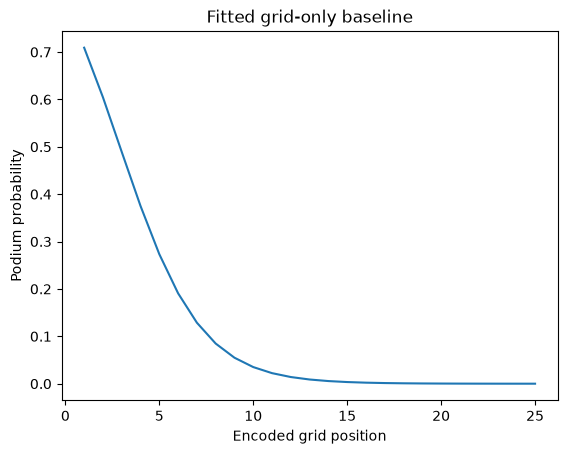

In [3]:
grid=pd.DataFrame({'grid_position':range(1,26)})
plt.plot(grid.grid_position,model.predict_proba(grid)[:,1]); plt.xlabel('Encoded grid position'); plt.ylabel('Podium probability'); plt.title('Fitted grid-only baseline'); plt.show()